# Replication of reskilling analysis from MSc thesis
Felix Zaussinger | 15.09.2022

**Core Analysis Goal(s)**
1. Replicate thesis approach based on updated data
2. Decide how to deal with skewed distribution when working with COOC matrix compared to ESCO matrix tables or Kanders Matrix
3. Understand and write down all of the assumptions that I make and reflect whether they are robust enough

**Key Insight(s)**
1. Replication based on ESCO v.1.1 is working!
2.
3.

In [1]:
import os
import scipy
import numpy as np
import pandas as pd
import geopandas as gpd
from pathlib import Path

from tqdm import tqdm
from mapping_career_causeways.compare_nodes_utils import find_closest

import seaborn as sns
import matplotlib.pyplot as plt

# load paths
from src import utils
from src.data.lfs import EuLfs
from src.modelling.reskilling import ReskillingPathways
from src.data.framework import Esco

useful_paths = utils.UsefulPaths()

# OPTIONAL: Load the "autoreload" extension so that code can change
%load_ext autoreload

# OPTIONAL: always reload modules so that as you change code in src, it gets loaded
%autoreload 2

# Settings
%matplotlib inline
%config InlineBackend.figure_format = 'retina'
pd.options.display.float_format = "{:,.2f}".format

sns.set_context("paper", font_scale=1.5, rc={"figure.dpi": 72})
sns.set_style("ticks")

#### Load data

##### Auxillary data

In [2]:
# Read geodata with NUTS regions
gdf = gpd.read_file(
    os.path.join(
        useful_paths.data_raw,
        "geodata",
        "NUTS_RG_03M_2021_4326_LEVL_2",
        "NUTS_RG_03M_2021_4326_LEVL_2.shp",
    )
)

##### LFS data

In [3]:
# esco data
esco = Esco()

# EU-LFS data
config = utils.load_config(os.path.join(useful_paths.config_dir, "eu_lfs_config.yml"))
lfs = EuLfs(config=config)
year = 2019

lfs_data = lfs.read_preprocessed_file(
    year=year,
    input_fname_lfs="eu_lfs_merged_{year}_with_final_unweighted_shares_and_earnings_incdecil_imputed",
)

#### Initialise reskilling simulation

In [4]:
# reskilling simulations
osm_version = "weighted"
sim_metric = "cooc"
diagonal_zeros = False

rp = ReskillingPathways(
    osm_version=osm_version, sim_metric=sim_metric, lfs_data=lfs_data, year=year
)

In [5]:
df_occs = rp.get_occs()

#### Computing occupation similarity at ISCO-3D level

Notes
- occupation distance measure at ISCO 3D level (todo: aggregate from ESCO)
- additional covariates: income deciles, skill level as proxy for education, ...
- analysis will be slightly different than the Nesta approach

Questions
- calculate average skill profile of 3D groups is calculated from occ-skills matrix (not possible for Kanders matrix as I miss the input data)

Decision
- use self-calculated, weighted occ-skills matrix
- compute avg skills profiles at ISCO 3D level

In [6]:
# read occ sim matrix
df_occ_sims = rp.sim_matrix_at_level(level="isco_3_digit", mask_diagonal=True)

# create numpy matrix and fill diagonal with zeros (avoid self-transitions)
similarity_matrix = df_occ_sims.copy().values
#np.fill_diagonal(similarity_matrix, 0)

#### Calibrate transition thresholds

##### Calculate within-group occupation similarities for different granularity levels

In [7]:
df_occ_sim = rp.df_occ_sim
df_sim_container = rp.calc_sim_means_by_level()

##### Plot results

In [8]:
rp.transition_thresholds = rp.calc_transition_thresholds(show_plots=False)
rp.transition_thresholds

,mean,sd,mean-sd,mean+sd,threshold_category
esco_5_digit,22.35,11.55,10.80,33.90,viable_high
isco_4_digit,14.47,10.79,3.68,25.26,viable
isco_3_digit,9.06,8.06,1.00,17.12,viable_low


<Figure size 432x288 with 0 Axes>

<Figure size 432x288 with 0 Axes>

<Figure size 432x288 with 0 Axes>

<Figure size 432x288 with 0 Axes>

##### Percentiles of overall distribution
1.616368047779022 6.500853535353546

In [9]:
q_viable, q_highly_viable = rp.trans_thresh_pc_approach
print(q_viable, q_highly_viable)

2.25 7.5


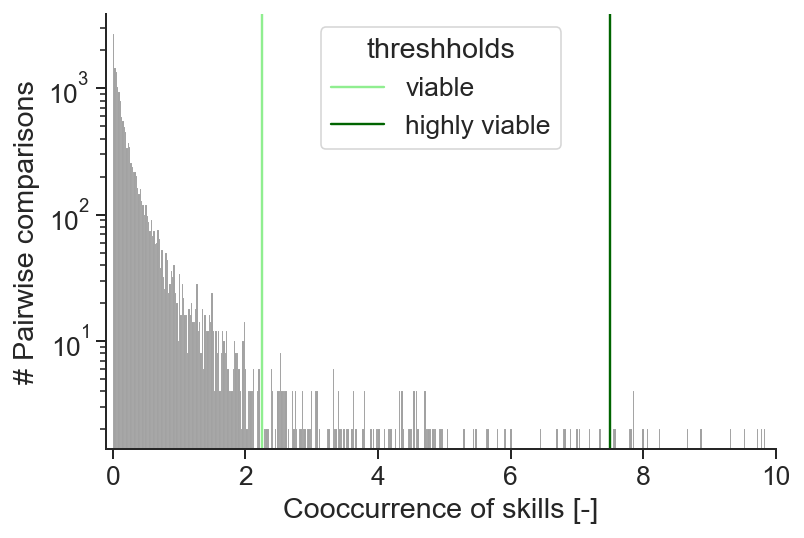

In [10]:
ax = sns.histplot(df_occ_sims.values.flatten(), color="grey", log_scale=(False, True))
ax.set_xlim(-0.1, 10)
ax.axvline(q_viable, color="lightgreen", label="viable")
ax.axvline(q_highly_viable, color="darkgreen", label="highly viable")
ax.set_ylabel("# Pairwise comparisons")
ax.set_xlabel("Cooccurrence of skills [-]")
plt.legend(loc="upper center", title="threshholds")
sns.despine()

##### Plot occ sim matrix at ISCO 3 digit level

<AxesSubplot:xlabel='Target occupations (isco_3_digit)', ylabel='Source occupations (isco_3_digit)'>

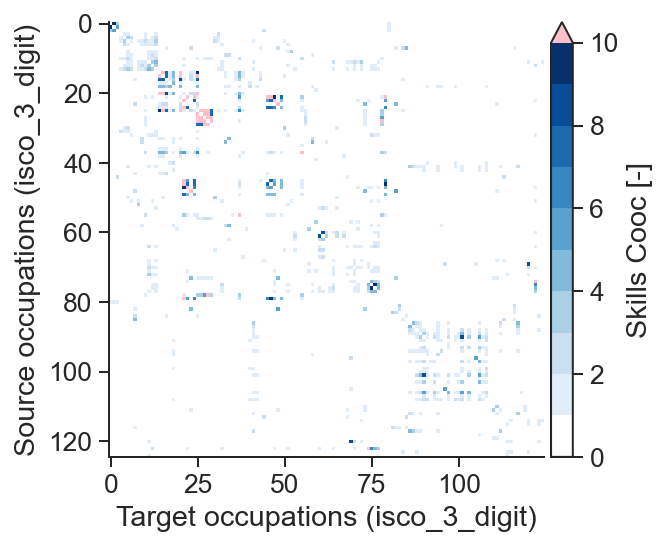

In [11]:
rp.plot_sim_matrix_at_level(vmax=10, mask_upper=False)

##### Plot occupation similarity matrix classified viable/highly viable

<AxesSubplot:xlabel='Target occupations (isco_4_digit)', ylabel='Source occupations (isco_4_digit)'>

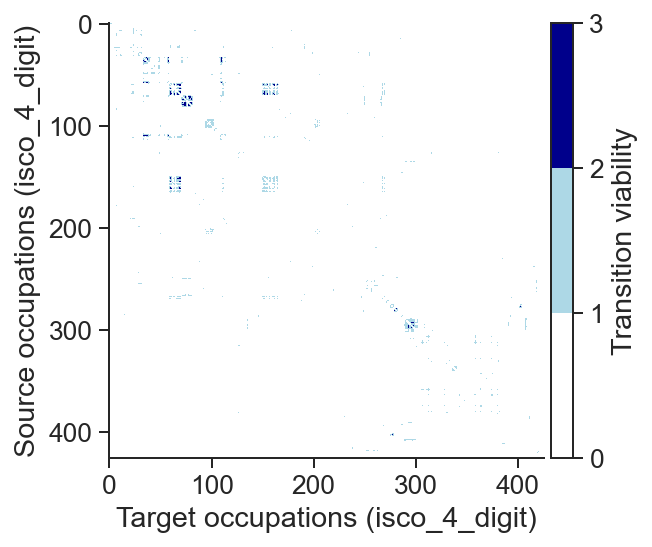

In [12]:
rp.plot_sim_matrix_at_level(level="isco_4_digit", classify=True, mask_upper=False)

#### Transition analysis logic
Base the quantile on the respective quantiles of the viable/highly viable transition categories in the Kanders matrix
- Viable: 96th percentile
- Highly viable: 99th percentile

#### Manually check some transitions

In [13]:
rp.coal_occupations

{'Mining, manufacturing and construction supervisors': '312',
 'Mining and mineral processing plant operators': '811',
 'Manufacturing, mining, construction, and distribution managers': '132',
 'Mining and construction labourers': '931'}

In [14]:
occ = df_occs.loc[
    df_occs.preferredLabel == "Mining and mineral processing plant operators"
]
print(occ.preferredLabel)

transitions = find_closest(
    i=occ.index.values[0], similarity_matrix=similarity_matrix, df=df_occs
)

transitions.head(5)

100    Mining and mineral processing plant operators
Name: preferredLabel, dtype: object


,conceptUri,preferredLabel,code,similarity
90,http://data.europa.eu/esco/isco/C722,"Blacksmiths, toolmakers and related trades wor...",722,1.78
101,http://data.europa.eu/esco/isco/C812,Metal processing and finishing plant operators,812,1.72
106,http://data.europa.eu/esco/isco/C817,Wood processing and papermaking plant operators,817,1.58
103,http://data.europa.eu/esco/isco/C814,"Rubber, plastic and paper products machine ope...",814,1.41
89,http://data.europa.eu/esco/isco/C721,"Sheet and structural metal workers, moulders a...",721,1.08


##### Check the skills distribution at the ISCO 3-digit level

<AxesSubplot:ylabel='Frequency'>

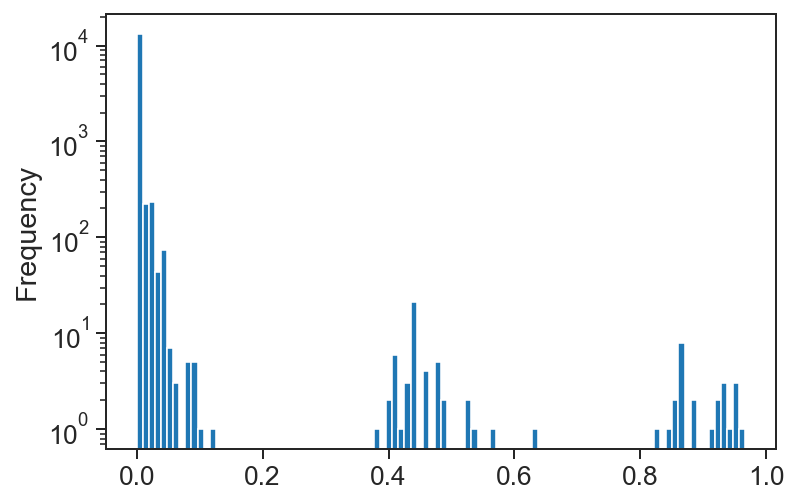

In [15]:
rp.occ_skills_mat_3d.iloc[25, :].plot.hist(bins=100, logy=True)

### Analyse number of viable transitions

In [16]:
countries = [
    "AT",
    "BE",
    "CH",
    "CY",
    "CZ",
    "DE",
    "DK",
    "EE",
    "ES",
    "FI",
    "FR",
    "GR",
    "HR",
    "HU",
    "IE",
    "IS",
    "IT",
    "LT",
    "LU",
    "LV",
    "NL",
    "NO",
    "PT",
    "RO",
    "SE",
    "SK",
    "UK",
]

In [17]:
# modelling settings
scenarios = ["coal"]
upskilling_modes = [None] #, "random", "computer_literacy", "coreness_weighted", "coreness_percentile", "optimal"]
optimise = "wage"

# thresholds used for first set of results. Lower than the percentile-based thresholds.
transition_thresholds = 1.616368047779022, 6.500853535353546

# results storage
results_dir = os.path.join(useful_paths.figure_dir, "reskilling_simulation_test")

In [18]:
simulation_results = rp.simulate(
    level="isco_3_digit",
    countries=countries,
    scenarios=["coal"],
    transition_optimisation=optimise,
    reskilling=None,
    mask_diagonal=True,
    transition_thresholds=transition_thresholds,
    out_dir=results_dir,
)

scenario: coal


In [19]:
rp.visualise_simulation_results_eu(
    simulation_results=simulation_results,
    transition_optimisation="wage",
    version="baseline",
    vmax_wages=100,
    vmax_transitions=8,
    base_dir=results_dir
)

<Figure size 720x360 with 0 Axes>

<Figure size 720x360 with 0 Axes>

##### Create visualisation

In [21]:
# Visualise results
rp.visualise_simulation_results_eu(
    simulation_results=None,
    transition_optimisation="wage",
    version="baseline",
    vmax_wages=100,
    vmax_transitions=8,
    base_dir=results_dir
)

<Figure size 720x360 with 0 Axes>

<Figure size 720x360 with 0 Axes>

#### Scenario 2b) Wage continuity + regional constraint

##### Regional distribution of unique occupations
Needed for regional reskilling constraint.

In Germany, over 90% of all unique 3-digit occupations have COEFF > 0 in each NUTS2 region

In [186]:
occ_number_by_nuts2_and_isco3 = lfs_data.groupby(["NUTS_ID", "ISCO3D"]).aggregate(
    {
        "COEFF": np.sum,
        'COEFF_share_brown_sl': np.sum,
        'COEFF_share_brown_slt': np.sum,
        'COEFF_share_green': np.sum,
        'COEFF_share_neutral_sl': np.sum,
        'COEFF_share_neutral_slt': np.sum
    }
)

jobs_by_regions_countries = occ_number_by_nuts2_and_isco3.reset_index()
jobs_by_regions_countries["COUNTRYW"] = jobs_by_regions_countries["NUTS_ID"].str.slice(0, 2)

# create categories of aggregate target jobs for SL and SLT versions
jobs_by_regions_countries["COEFF_share_target_sl"] = jobs_by_regions_countries["COEFF_share_green"] + jobs_by_regions_countries["COEFF_share_neutral_sl"]
jobs_by_regions_countries["COEFF_share_target_slt"] = jobs_by_regions_countries["COEFF_share_green"] + jobs_by_regions_countries["COEFF_share_neutral_slt"]

# ceil all numeric results
numeric_cols = jobs_by_regions_countries.select_dtypes(include=[np.number]).columns.values
jobs_by_regions_countries[numeric_cols] = jobs_by_regions_countries[numeric_cols].apply(np.ceil, axis=1)
jobs_by_regions_countries

,NUTS_ID,ISCO3D,COEFF,COEFF_share_brown_sl,COEFF_share_brown_slt,COEFF_share_green,COEFF_share_neutral_sl,COEFF_share_neutral_slt,COUNTRYW,COEFF_share_target_sl,COEFF_share_target_slt
0,AT11,100,0.00,0.00,0.00,0.00,0.00,0.00,AT,0.00,0.00
1,AT11,110,0.00,0.00,0.00,0.00,0.00,0.00,AT,0.00,0.00
2,AT11,111,811.00,0.00,0.00,0.00,811.00,811.00,AT,811.00,811.00
3,AT11,112,711.00,0.00,0.00,0.00,711.00,711.00,AT,711.00,711.00
4,AT11,120,0.00,0.00,0.00,0.00,0.00,0.00,AT,0.00,0.00
...,...,...,...,...,...,...,...,...,...,...,...
37345,UKN,951,0.00,0.00,0.00,0.00,0.00,0.00,UK,0.00,0.00
37346,UKN,952,686.00,0.00,0.00,0.00,686.00,686.00,UK,686.00,686.00
37347,UKN,960,0.00,0.00,0.00,0.00,0.00,0.00,UK,0.00,0.00
37348,UKN,961,"1,646.00",0.00,0.00,"1,234.00",412.00,412.00,UK,"1,646.00","1,646.00"


##### Compute transitions

In [209]:
country = "DE"
scenario = "coal"

# unique regions
df = lfs_data[lfs_data["COUNTRYW"] == country]

# select scenario-specific weighting coefficient
coeff_weight = rp.transition_pool_weights[scenario]

# jobs by region
jobs_by_regions = jobs_by_regions_countries[jobs_by_regions_countries["COUNTRYW"] == country]

# fraction of total current jobs in (neutral or green) target occupation B that could be added to employ workers transitioning from (brown) source occupation A
max_frac = 0.05

# job availability by region
numeric_cols = jobs_by_regions.select_dtypes(include=[np.number]).columns.values
jobs_by_regions[numeric_cols] = np.ceil(jobs_by_regions[numeric_cols] * max_frac)

# sim matrix
similarity_matrix = rp.sim_matrix_at_level(
    level="isco_3_digit", mask_diagonal=True
).values

# viability threshold
q_viable = 1.6

C:\Users\fzaussinger\AppData\Local\Temp\ipykernel_16052\2393062043.py:18: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  jobs_by_regions[numeric_cols] = np.ceil(jobs_by_regions[numeric_cols] * max_frac)


In [210]:
jobs_by_regions

,NUTS_ID,ISCO3D,COEFF,COEFF_share_brown_sl,COEFF_share_brown_slt,COEFF_share_green,COEFF_share_neutral_sl,COEFF_share_neutral_slt,COUNTRYW,COEFF_share_target_sl,COEFF_share_target_slt
5810,DE11,100,0.00,0.00,0.00,0.00,0.00,0.00,DE,0.00,0.00
5811,DE11,110,0.00,0.00,0.00,0.00,0.00,0.00,DE,0.00,0.00
5812,DE11,111,84.00,0.00,0.00,0.00,84.00,84.00,DE,84.00,84.00
5813,DE11,112,"1,923.00",0.00,0.00,0.00,"1,923.00","1,923.00",DE,"1,923.00","1,923.00"
5814,DE11,120,0.00,0.00,0.00,0.00,0.00,0.00,DE,0.00,0.00
...,...,...,...,...,...,...,...,...,...,...,...
12113,DEG0,951,0.00,0.00,0.00,0.00,0.00,0.00,DE,0.00,0.00
12114,DEG0,952,0.00,0.00,0.00,0.00,0.00,0.00,DE,0.00,0.00
12115,DEG0,960,0.00,0.00,0.00,0.00,0.00,0.00,DE,0.00,0.00
12116,DEG0,961,72.00,0.00,0.00,54.00,18.00,18.00,DE,72.00,72.00


In [344]:
%%time

# TODO: for country in countries

# select scenario- and country-specific transition pool
df_transition_pool = rp.define_transition_pool(
    scenario=scenario, country=country
)

# read occupation list coherent with sim matrix and enriched by means
# across several LFS variables
df_occs = rp.get_occs(
    level="isco_3_digit",
    lfs_country_subset=lfs_data[
        lfs_data["COUNTRYW"] == country
    ],
)

# nuts codes
nuts_codes = df.NUTS_ID.unique()

# 2) loop over regions
# ------------------------------------------------------------------------------------------
results_by_region = {}
jobs_by_regions_updated = {}
for nuts_code in tqdm(nuts_codes):
    print(nuts_code)

    # absolute n of jobs in region per occupation category
    # bookkeeping of regional constraints in absorptive employment capacity has to happen here (!)
    jobs_by_region = jobs_by_regions[
        jobs_by_regions.NUTS_ID == nuts_code
        ]

    # regional subset of transition pool
    regional_transition_pool = df_transition_pool.loc[
        df_transition_pool["NUTS_ID"] == nuts_code
    ]

    # regional subset of source occupations
    src_occ_groups = list(regional_transition_pool.ISCO3D.unique())

    # shuffle order to randomise the next loop
    np.random.shuffle(src_occ_groups) # .sample(frac=1)

    #print("regional occs: ", len(src_occ_groups))
    #print("number of at-risk jobs:", regional_transition_pool.COEFF.sum())

    # 3) loop over (brown) source occupation categories (ISCO 3-digit)
    # --------------------------------------------------------------------------------------
    transition_number_data = []
    for i, src_occ_group in enumerate(src_occ_groups):
        # print("Source occupation:", src_occ_group)

        # pool of transitioning workers in region i and occupation j
        src_workers = regional_transition_pool[
            regional_transition_pool.ISCO3D == src_occ_group
            ]

        # ceil number of workers searching new job
        src_workers[coeff_weight] = np.ceil(src_workers[coeff_weight])

        # absolute number of transitioning workers in region i and occupation j
        n_workers_transitioning = src_workers[coeff_weight].sum()
        # print("number of workers transitioning: ", n_workers_transitioning)

        # find index of search occ and closest target occs
        idx = df_occs.loc[df_occs["code"] == src_occ_group].index.values[0]
        target_occs = find_closest(
            i=idx, similarity_matrix=similarity_matrix, df=df_occs
        )

        # filter criteria 1: sim > viability threshold
        target_occs_filtered = target_occs.loc[target_occs.similarity > q_viable]

        # filter criteria 2: target occupation is neutral or green
        target_occs_filtered = target_occs_filtered.loc[
            (target_occs_filtered["category_sl"] != "brown") &
            (~target_occs_filtered["code"].isin(list(rp.coal_occupations.values())))
        ]
        target_occs_filtered = target_occs_filtered.dropna()

        # combine with job availability at regional level
        target_occs_filtered = target_occs_filtered.merge(
            jobs_by_region,
            left_on="code",
            right_on="ISCO3D",
            how="left",
            #suffixes=("", "_target_regional"),
        )

        # ceil number of typically available jobs in target occupations
        target_occs_filtered[coeff_weight] = np.ceil(target_occs_filtered[coeff_weight])

        # sort target occs by wage
        target_occs_filtered = target_occs_filtered.sort_values("annual_earnings", ascending=False)
        n_targets = len(target_occs_filtered)
        # print("pool of viable transition options", n_targets)
        # print("")

        # absolute number of new jobs that can likely be absorbed in this region and occupation
        #target_occs_filtered["COEFF_max_absorption"] = np.ceil(target_occs_filtered[coeff_weight] * max_frac)
        #target_occs_filtered["COEFF_absorbed"] = 0

        # shuffle order in which workers change job
        # idea: could weight by inverse age, but idk how valid of an assumption that is (job transition probability might be more gaussian-shaped)
        src_workers = src_workers.sample(frac=1)

        # check if viable transition exists
        if not target_occs_filtered.empty:
            # NEED TO START ITERATING OVER INDIVIDUAL WORKERS HERE
            for i, src_worker in src_workers.iterrows():
                # go through potential choices ranked by wage
                rank = 0
                while rank <= n_targets-1:
                    # print("rank", rank)

                    # filter criteria 3: workers choose the viable target occupation that provides the best wage
                    target = target_occs_filtered.iloc[rank, :]

                    # check job availability of region-occupation pair
                    target_job_availability = jobs_by_region.loc[jobs_by_region["ISCO3D"] == target["code"], "COEFF"].values[0]

                    # print("target_job_availability", target_job_availability)
                    # print("src worker coeff", src_worker["COEFF"])

                    # if the target occupation can regionally absorb all transitioning workers, every worker chooses this transition
                    if target_job_availability > src_worker["COEFF"]:
                        if rank == 0:
                            pass
                            # print("choosing first-best option:", target["code"])
                        # target occupation
                        src_worker["transition_viable"] = True
                        src_worker["transition_target"] = target["preferredLabel"]
                        src_worker["transition_target_code"] = target["code"]
                        # todo: target category should be scenario-dependent, not hardcoded!!
                        src_worker["target_category"] = target["category_sl"]

                        # stats on # of viable transitions
                        src_worker["n_viable_transitions"] = target_occs_filtered.shape[0]
                        src_worker["n_viable_transitions_sum"] = (
                                src_worker["n_viable_transitions"] * src_worker[coeff_weight]
                        )

                        # wage difference
                        src_worker["earnings_delta_closest_switch"] = (
                                target["annual_earnings"] - src_worker["annual_earnings"]
                        )
                        src_worker["earnings_delta_closest_switch_sum"] = src_worker["earnings_delta_closest_switch"] * src_worker[coeff_weight]

                        # update post-transition availability
                        # print(jobs_by_region.loc[jobs_by_region["ISCO3D"] == target["code"], "COEFF"].values[0])
                        jobs_by_region.loc[jobs_by_region["ISCO3D"] == target["code"], ["COEFF"]] -= src_worker["COEFF"]
                        # print(jobs_by_region.loc[jobs_by_region["ISCO3D"] == target["code"], "COEFF"].values[0])
                        break
                    else:
                        # print("evaluating next-best option")
                        # jump to target occupation with next-best rank
                        rank += 1
                        continue
                # print("")
                transition_number_data.append(src_worker)
                jobs_by_regions_updated[nuts_code] = jobs_by_region
        else:
            # if no viable transition exists, I assume (FOR NOW), that the salary is lost entirely and has to be provided by the state (a bit unrealistic)
            src_workers[
                "earnings_delta_closest_switch"
            ] = src_workers["annual_earnings"] * (-1)
            src_workers["earnings_delta_closest_switch_sum"] = (
                    src_workers["earnings_delta_closest_switch"] * src_workers[coeff_weight]
            )
            src_workers["n_viable_transitions"] = 0
            src_workers["n_viable_transitions_sum"] = 0
            src_workers["transition_viable"] = False
            src_workers["transition_target"] = None
            src_workers["transition_target_code"] = None
            src_workers["target_category"] = None

            # add one by one (workaround)
            for i, src_worker in src_workers.iterrows():
                transition_number_data.append(src_worker)

    results_by_region[nuts_code] = transition_number_data

    # delete after
    #break

# combine to df
df_results_by_region = pd.concat(list(results_by_region.values()[0]), axis=1).T
df_results_by_region

  0%|          | 0/39 [00:00<?, ?it/s]<timed exec>:59: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
<timed exec>:59: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
<timed exec>:59: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  3%|▎         | 1/39 [00:00<00:06,  6.21it/s]<

DE11
DE12


<timed exec>:59: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
<timed exec>:59: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
<timed exec>:59: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  8%|▊         | 3/39 [00:00<00:03, 11.08it/s]<timed exec>:59: SettingWithCopyWarning

DE14
DE13
DE27


<timed exec>:59: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
<timed exec>:59: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
<timed exec>:59: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
 13%|█▎        | 5/39 [00:00<00:03,  9.92it/s]<timed exec>:59: SettingWithCopyWarning

...

DE50
DEF0
DE80
DE93
DEB1


<timed exec>:59: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
<timed exec>:59: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
<timed exec>:59: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
 95%|█████████▍| 37/39 [00:03<00:00, 15.77it/s]

DE72
DEB2
DED5
DEE0


<timed exec>:59: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
<timed exec>:59: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
<timed exec>:59: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
100%|██████████| 39/39 [00:03<00:00, 11.97it/s]


TypeError: 'dict_values' object is not subscriptable

In [353]:
list(results_by_region.values())[0]

14

In [338]:
idx = ["COUNTRYW", "NUTS_ID", "ISCO3D"]
jobs_by_region_original = jobs_by_regions[
    jobs_by_regions.NUTS_ID == nuts_code
]
jobs_by_region.set_index(idx) / jobs_by_region_original.set_index(idx)

COEFF  COEFF_share_brown_sl  COEFF_share_brown_slt  \
COUNTRYW NUTS_ID ISCO3D                                                       
DE       DE11    100       NaN                   NaN                    NaN   
                 110       NaN                   NaN                    NaN   
                 111      1.00                   NaN                    NaN   
                 112      1.00                   NaN                    NaN   
                 120       NaN                   NaN                    NaN   
...                        ...                   ...                    ...   
                 951       NaN                   NaN                    NaN   
                 952       NaN                   NaN                    NaN   
                 960       NaN                   NaN                    NaN   
                 961      1.00                   NaN                    NaN   
                 962      1.00                   NaN                    NaN   

                         COEFF_share_green  COEFF_share_neutral_sl  \
COUNTRYW NUTS_ID ISCO3D                                              
DE       DE11    100                   NaN                     NaN   
                 110                   NaN                     NaN   
                 111                   NaN                    1.00   
                 112                   NaN                    1.00   
                 120                   NaN                     NaN   
...                                    ...                     ...   
                 951                   NaN                     NaN   
                 952                   NaN                     NaN   
                 960                   NaN                     NaN   
                 961                  1.00                    1.00   
                 962                   NaN                    1.00   

                         COEFF_share_neutral_slt  COEFF_share_target_sl  \
COUNTRYW NUTS_ID ISCO3D                                                   
DE       DE11    100                         NaN                    NaN   
                 110                         NaN                    NaN   
                 111                        1.00                   1.00   
                 112                        1.00                   1.00   
                 120                         NaN                    NaN   
...                                          ...                    ...   
                 951                         NaN                    NaN   
                 952                         NaN                    NaN   
                 960                         NaN                    NaN   
                 961                        1.00                   1.00   
                 962                        1.00                   1.00   

                         COEFF_share_target_slt  
COUNTRYW NUTS_ID ISCO3D                          
DE       DE11    100                        NaN  
                 110                        NaN  
                 111                       1.00  
                 112                       1.00  
                 120                        NaN  
...                                         ...  
                 951                        NaN  
                 952                        NaN  
                 960                        NaN  
                 961                       1.00  
                 962                       1.00  

[166 rows x 8 columns]

In [ ]:
assert 1 == 2

## Upskilling analysis
- use stylised results from the upskilling analyis
- add skills that were found to unlock the most additional viable transitions per occupation to profile before calculating transitions
- pre-compute 4 different similarity matrices where those skills are already added

In [ ]:
df_top_skills_per_occ = pd.read_csv(
    os.path.join(
        useful_paths.data_interim,
        "upskilling_analysis",
        "upskilling_best_5_skills_per_isco3d_occupation.csv",
    ),
    index_col=0,
)

df_top_skills_per_occ

if two skills unlock the same (top) number of new viable transitions, choose the one with the higher coreness

In [ ]:
isco_groups = esco.isco_groups
isco_groups_3d = isco_groups[isco_groups.code.str.len() == 3]
isco_group_dict = dict(zip(isco_groups_3d.preferredLabel, isco_groups_3d.code))

In [ ]:
optimal_upskilling_per_occ = []
for group, df in df_top_skills_per_occ.groupby("Occupation"):
    # max new viable transitions
    t_max = df["Viable transitions"].max()
    sub_df = df[df["Viable transitions"] == t_max]

    # max coreness if multiple options
    c_max = sub_df["Coreness"].max()
    sub_sub_df = sub_df[sub_df["Coreness"] == c_max]
    optimal_upskilling_per_occ.append(sub_sub_df)

df_optimal_upskilling_per_occ = pd.concat(
    optimal_upskilling_per_occ, axis=0
).reset_index(drop=True)

# get skill id
# todo: refactor to point to MCC repository
coreness = pd.read_csv(
    os.path.join(useful_paths.data_processed, "esco", "skills_network_metrics.csv"),
    index_col=0,
)

df_optimal_upskilling_per_occ = pd.merge(
    df_optimal_upskilling_per_occ,
    coreness.reset_index()[["index", "preferredLabel"]].rename(
        columns={"preferredLabel": "Skill", "index": "id_skill"}
    ),
    on="Skill",
)

df_optimal_upskilling_per_occ["id_occ"] = [
    isco_group_dict[occ_label]
    for occ_label in df_optimal_upskilling_per_occ.Occupation.values
]

df_optimal_upskilling_per_occ.to_csv(
    os.path.join(
        useful_paths.data_interim,
        "upskilling_analysis",
        "upskilling_selected_skill_per_occupation.csv",
    )
)
df_optimal_upskilling_per_occ

In [ ]:
occ_sims_isco3 = df_occ_sims.values
np.fill_diagonal(occ_sims_isco3, 0)

In [ ]:
occ_codes = rp.get_occs()
occ_codes

In [ ]:
from src.modelling.occupation_distance import occ_sim_matrix_by_levels

occ = df_optimal_upskilling_per_occ.iloc[0]
occ_sim_matrix_by_levels(upskilling_ids=(occ.id_occ, occ.id_skill))

In [ ]:
occ = df_optimal_upskilling_per_occ.iloc[0]
print(occ)

# find index of occ
idx_occ = occ_codes[occ_codes.code == occ.id_occ].index.values[0]
idx_new_skill = occ.id_skill
print(idx_occ, idx_new_skill)

# add skill to occ skill profile
occ_skills_mat_isco3_upskilling = occ_skills_mat_isco3.copy()
occ_skills_mat_isco3_upskilling.iloc[idx_occ, idx_new_skill] = 1

# recalc occ sim matrix
occ_sims_isco3_upskilling = np.matmul(
    occ_skills_mat_isco3_upskilling.values,
    occ_skills_mat_isco3_upskilling.values.transpose(),
)
np.fill_diagonal(occ_sims_isco3_upskilling, 0)

In [ ]:
rp.get_occs()

#### 1) Skills continuity scenario with upskilling

In [ ]:
%%time
if run_skills_continuity_scenarios:
    transition_number_data = []

    for i, src_worker in tqdm(df_transition_pool.iterrows()):

        search_label = src_worker.ISCO3D_label
        idx = df_occs.loc[df_occs.occ == search_label].index.values[0]

        # -----------------------------------------------------------------------------------------------------------------------------
        # UPSKILLING STEP
        # -----------------------------------------------------------------------------------------------------------------------------
        # conditional on the source occupation, upskill worker with the skill unlocking the highest number of new viable transitions
        upskilling_data = df_optimal_upskilling_per_occ.loc[
            df_optimal_upskilling_per_occ.Occupation == search_label
        ]

        # find index of occ
        idx_occ = occ_codes.index(upskilling_data.id_occ.values[0])
        idx_new_skill = upskilling_data.id_skill

        # add skill to occ skill profile
        occ_skills_mat_isco3_upskilling = occ_skills_mat_isco3.copy()
        occ_skills_mat_isco3_upskilling.iloc[idx_occ, idx_new_skill] = 1

        # recalc occ sim matrix
        occ_sims_isco3_upskilling = np.matmul(
            occ_skills_mat_isco3_upskilling.values,
            occ_skills_mat_isco3_upskilling.values.transpose(),
        )
        np.fill_diagonal(occ_sims_isco3_upskilling, 0)

        # find closest transitions
        target_occs = find_closest(
            i=idx, similarity_matrix=occ_sims_isco3_upskilling, df=df_occs
        )

        # filter
        target_occs_filtered = target_occs.loc[target_occs.similarity > q_viable]
        target_occs_filtered = target_occs_filtered.loc[
            target_occs_filtered.category != "brown"
        ]
        target_occs_filtered = target_occs_filtered.dropna()

        # earnings delta to next closest occupation
        target = target_occs_filtered.head(1)

        # check if viable transition exists
        if not target.empty:
            # Every worker transitions to the next-closest job and I evaluate the wage difference
            src_worker["earnings_delta_closest_switch"] = (
                    target.annual_earnings_2016.values[0] - src_worker.annual_earnings_2016
            )
            src_worker["earnings_delta_closest_switch_sum"] = (
                                                                      target.annual_earnings_2016.values[0] - src_worker.annual_earnings_2016
            ) * src_worker[transition_pool_weights]
            src_worker["n_viable_transitions"] = target_occs_filtered.shape[0]
            src_worker["n_viable_transitions_sum"] = (
                    target_occs_filtered.shape[0] * src_worker[transition_pool_weights]
            )
            src_worker["transition_viable"] = True
            src_worker["transition_target"] = target.occ.values[0]
            src_worker["target_category"] = target.category.values[0]
        else:
            # if no viable transition exists, I assume (FOR NOW), that the salary is lost entirely and has to be provided by the state (a bit unrealistic)
            src_worker[
                "earnings_delta_closest_switch"
            ] = src_worker.annual_earnings_2016 * (-1)
            src_worker["earnings_delta_closest_switch_sum"] = (
                    src_worker.annual_earnings_2016
                    * (-1)
                    * src_worker[transition_pool_weights]
            )
            src_worker["n_viable_transitions"] = 0
            src_worker["n_viable_transitions_sum"] = 0
            src_worker["transition_viable"] = False
            src_worker["transition_target"] = None
            src_worker["target_category"] = None

        transition_number_data.append(src_worker)

    # to df
    df_transition_numbers = pd.concat(transition_number_data, axis=1).T
    df_transition_numbers = df_transition_numbers.infer_objects()

    # Calculate avg number of transitions per threatened job
    df_transition_numbers_by_nuts = df_transition_numbers.groupby("NUTS_ID").sum()
    df_transition_numbers_by_nuts["n_viable_transitions_rel"] = (
        df_transition_numbers_by_nuts.n_viable_transitions_sum
        / df_transition_numbers_by_nuts[transition_pool_weights]
    )

    # to gdf
    gdf_transition_numbers_by_nuts = pd.merge(
        gdf.query("CNTR_CODE == 'DE'"),
        df_transition_numbers_by_nuts.reset_index(),
        on="NUTS_ID",
        how="left",
    )

    # PLOTS

    # TRANSITION NUMBERS
    ax = gdf_transition_numbers_by_nuts.plot(
        column="n_viable_transitions_rel",
        figsize=(10, 10),
        legend=True,
        cmap=cmap_transitions,
        vmin=0,
        vmax=vmax_transitions,
        legend_kwds={
            "label": "Viable transitions per threatened job [-]",
            "fraction": 0.03,
            "extend": "max",
        },
        missing_kwds={"facecolor": "lightgrey", "hatch": "/", "edgecolor": "grey"},
        edgecolor="grey",
        linewidth=0.5,
    )
    gdf_transition_numbers_by_nuts.apply(
        lambda x: ax.annotate(
            text=x.NUTS_NAME,
            xy=x.geometry.centroid.coords[0],
            ha="center",
            alpha=0.5,
            rotation=0,
            fontsize=8,
        ),
        axis=1,
    )

    # ax.set_title("Viable transitions (upskilling)")
    ax.axis("off")

    # EARNINGS LOSSES
    cmap = plt.get_cmap("RdYlGn")
    v = vmax_wages
    gdf_transition_numbers_by_nuts["earnings_delta_closest_switch_sum"] = (
        gdf_transition_numbers_by_nuts["earnings_delta_closest_switch_sum"] / 10**6
    )
    ax = gdf_transition_numbers_by_nuts.plot(
        column="earnings_delta_closest_switch_sum",
        figsize=(10, 10),
        legend=True,
        cmap=cmap_earnings,
        vmin=-v,
        vmax=v,
        legend_kwds={
            "label": "Change in total annual earnings [Mio € in 2010]",
            "fraction": 0.03,
            "extend": "both",
        },
        missing_kwds={"facecolor": "lightgrey", "hatch": "/", "edgecolor": "grey"},
        edgecolor="grey",
        linewidth=0.5,
    )
    gdf_transition_numbers_by_nuts.apply(
        lambda x: ax.annotate(
            text=x.NUTS_NAME,
            xy=x.geometry.centroid.coords[0],
            ha="center",
            alpha=0.5,
            rotation=0,
            fontsize=8,
        ),
        axis=1,
    )

    ax.set_title("Skills continuity scenario (upskilling)")
    ax.axis("off")
    plt.tight_layout()

    # totals
    earnings_losses[
        "skills_continuity_upskilling"
    ] = gdf_transition_numbers_by_nuts.earnings_delta_closest_switch_sum.sum()

    print(
        np.abs(gdf_transition_numbers_by_nuts.earnings_delta_closest_switch_sum.sum())
        / (40 * 10**9)
    )
    gdf_transition_numbers_by_nuts.earnings_delta_closest_switch_sum.sum()

### Comparison of earnings losses across scenarios

In [ ]:
df_earnings_losses = pd.DataFrame.from_dict(
    earnings_losses, orient="index", columns=["annual_earnings_delta"]
)
df_earnings_losses.index.name = "scenario"
wage_scenario = df_earnings_losses.reset_index()
wage_scenario["annual_earnings_delta_mio"] = (
    wage_scenario["annual_earnings_delta"] / 10**6
)

In [ ]:
fig, ax = plt.subplots(figsize=(5, 8))
sns.barplot(
    data=wage_scenario,
    x="scenario",
    y="annual_earnings_delta_mio",
    ax=ax,
    zorder=2,
)

sns.despine()

ax.set_xlabel(None)
ax.set_ylabel("Change in total annual earnings [M€ (2019)]")

plt.xticks(np.arange(2), ["Before", "After"])
plt.grid(axis="y", linestyle="--", zorder=0)

plt.tight_layout()
plt.savefig(
    os.path.join(
        useful_paths.figure_dir,
        out_dir,
        "earnings_losses_comparison.png",
    ),
    dpi=300,
    bbox_inches="tight",
)

In [ ]:
fig, ax = plt.subplots(figsize=(8, 4))
sns.barplot(
    data=wage_scenario,
    y="scenario",
    x="annual_earnings_delta_mio",
    ax=ax,
    zorder=2,
    orient="h",
)

sns.despine()

ax.set_ylabel(None)
ax.set_xlabel("Change in total annual earnings [M€ (2019)]")

plt.yticks(np.arange(2), ["Before", "After"])
plt.grid(axis="x", linestyle="--", zorder=0)

plt.tight_layout()
plt.savefig(
    os.path.join(
        useful_paths.figure_dir,
        out_dir,
        "earnings_losses_comparison.png",
    ),
    dpi=300,
    bbox_inches="tight",
)

Pension in Germany with 67 years

In [ ]:
median_age_coal_workers = 52
pension_age = 67
age_delta = pension_age - median_age_coal_workers

wage_scenario["earnings_delta_mio_15yrs"] = (
    wage_scenario.annual_earnings_delta_mio * age_delta
)
wage_scenario